✅ GPU détecté : Tesla T4
   VRAM : 15.6 Go
   Device utilisé : cuda

📊 Architecture : 6 couches, d=256, 8 têtes
   Paramètres estimés : 8.9M

📥 Chargement du dataset WikiText-2...


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

   Tokenizer : tiktoken GPT-2 (vocab=50257)
   Tokenisation du corpus...
   Tokens train : 2,391,884
   Tokens val   : 247,289
   Batches train : 157
   Batches val   : 8
✅ Données prêtes !

🏗️  Modèle MiniLLM créé avec succès !
   Paramètres : 19,193,344 (19.19M)
   Architecture : 6 blocs × 8 têtes × d=256
   Test forward pass : logits shape = torch.Size([2, 32, 50257]), loss = 10.4306

  🔬 DÉBUT DE LA COMPARAISON DES OPTIMIZERS

────────────────────────────────────────────────────────────
  🚀 Entraînement : SGD + Momentum
────────────────────────────────────────────────────────────
  Step   50 | Train Loss: 8.9683 | Val Loss: 8.9308 | Val PPL: 7561.4 | LR: 1.00e-02 | 22ms/step
  Step  100 | Train Loss: 8.3604 | Val Loss: 8.3326 | Val PPL: 4157.4 | LR: 9.70e-03 | 23ms/step
  Step  150 | Train Loss: 8.2598 | Val Loss: 8.2343 | Val PPL: 3768.0 | LR: 8.83e-03 | 22ms/step
  Step  200 | Train Loss: 8.0245 | Val Loss: 8.1188 | Val PPL: 3356.9 | LR: 7.50e-03 | 22ms/step
  Step  250 | Train L

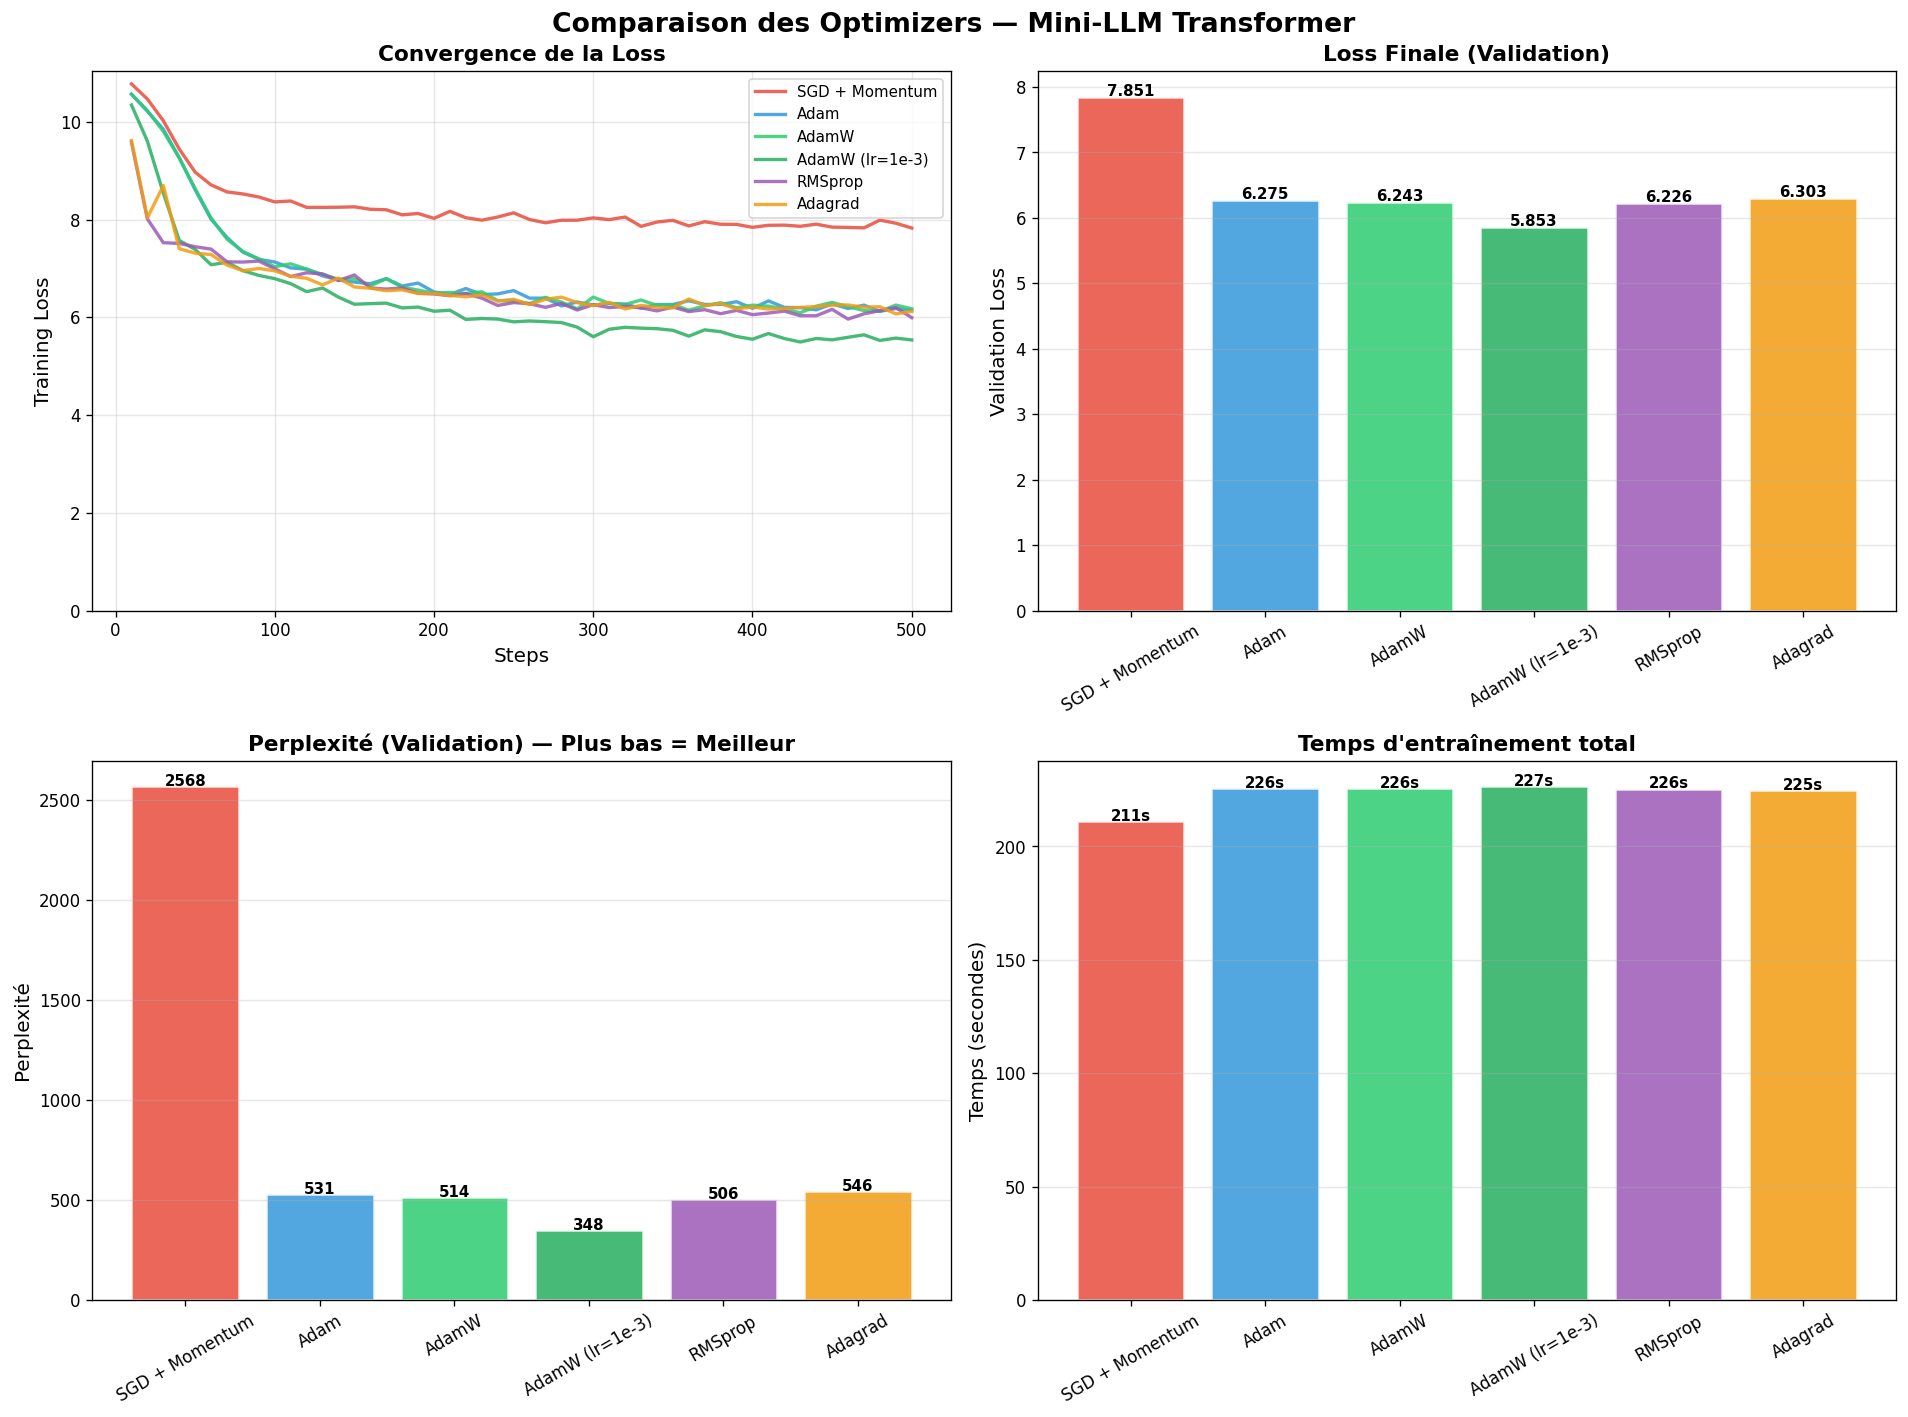

📊 Graphique sauvegardé : comparaison_optimizers.png


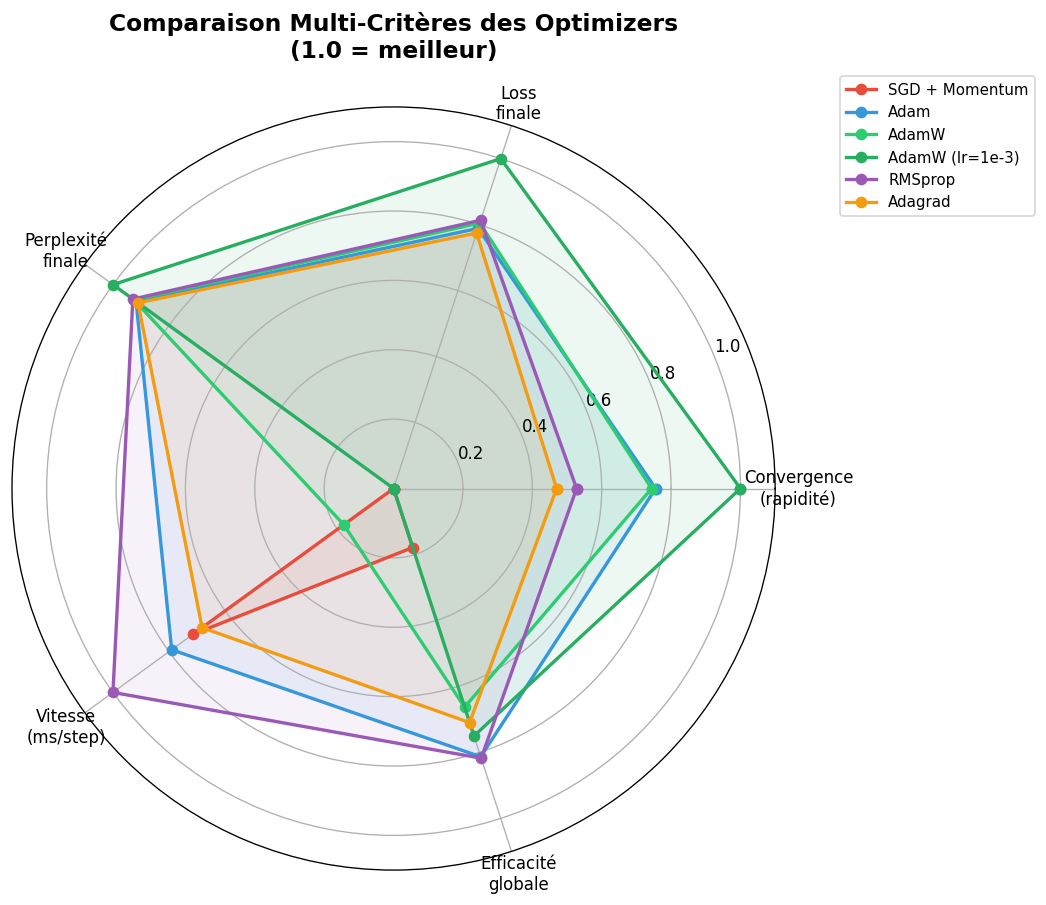

📊 Graphique sauvegardé : radar_optimizers.png


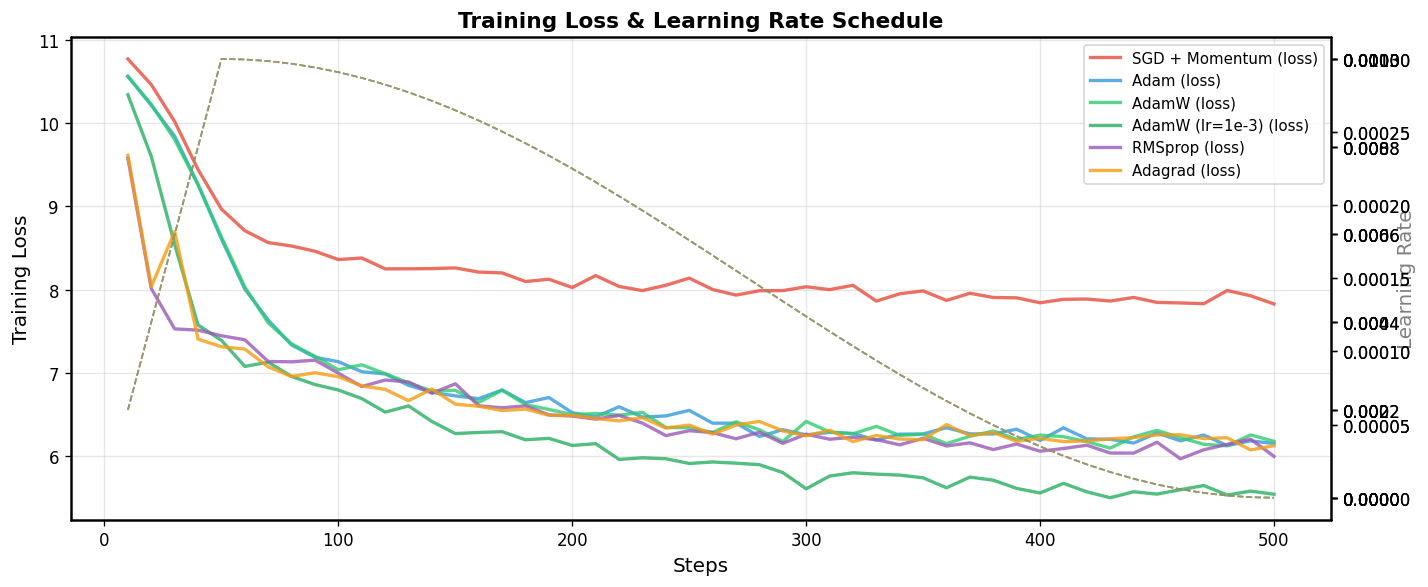


  📝 GÉNÉRATION DE TEXTE — Meilleur modèle

  Prompt: "The "
  → The 

 According to May 2011 , she had been to the third end of the episode of the release of the original time as " . " I. H.S.S.S. " The One of the 

  Prompt: "In the "
  → In the 

 = = 

 = = = = = 

 The film is a " ) ; the United States , with the name of the first two other " . The " was the " as an official role of 

  Prompt: "Science "
  → Science 

 = = = = = = = = = 

 = 

 The same year of the late 24th century , the end of the United States . The first " was a period of the US and wa

  Prompt: "Once upon "
  → Once upon 

 = = = = = = 

 The British government was the second , but the final line was a two months of the year . The series , the episode was nam

✅ Terminé ! Modèle entraîné avec AdamW (lr=1e-3).
💾 Résultats sauvegardés : resultats_comparaison.json
📊 Graphiques sauvegardés : comparaison_optimizers.png, radar_optimizers.png

🎓 Prêt pour le mémoire !


In [ ]:
"""
=============================================================================
  MINI-LLM FROM SCRATCH — Comparaison des Optimizers
  Projet de Fin d'Études — Master

  Ce notebook construit un petit Transformer Decoder (Language Model)
  depuis zéro en PyTorch, l'entraîne sur un corpus de texte,
  et compare 6 optimizers sur les mêmes conditions.

  Compatible : Google Colab (GPU T4 ou même CPU)
=============================================================================
"""

# ============================================================
# CELLULE 1 — Installation des dépendances
# ============================================================
# !pip install -q matplotlib pandas datasets tiktoken

# ============================================================
# CELLULE 2 — Imports
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math
import time
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import pandas as pd
import numpy as np
import copy
import gc
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Détection automatique du device
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"✅ GPU détecté : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} Go")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("✅ Apple Silicon GPU détecté")
else:
    DEVICE = torch.device("cpu")
    print("⚠️  Pas de GPU — entraînement sur CPU (plus lent mais fonctionnel)")

print(f"   Device utilisé : {DEVICE}")

# ============================================================
# CELLULE 3 — Hyperparamètres du modèle
# ============================================================
# Tu peux ajuster ces valeurs selon ta VRAM / temps disponible

CONFIG = {
    # Architecture du Transformer
    "vocab_size":     8192,     # taille du vocabulaire
    "d_model":        256,      # dimension des embeddings
    "n_heads":        8,        # nombre de têtes d'attention
    "n_layers":       6,        # nombre de blocs Transformer
    "d_ff":           1024,     # dimension du FFN (4 × d_model)
    "max_seq_len":    128,      # longueur max des séquences
    "dropout":        0.1,

    # Entraînement
    "batch_size":     64,
    "num_epochs":     5,
    "max_steps":      500,      # limite pour comparaison rapide
    "log_interval":   10,       # log toutes les N steps

    # Données
    "dataset_name":   "wikitext",
    "dataset_config": "wikitext-2-raw-v1",
    "train_samples":  10000,    # nombre de séquences d'entraînement
    "val_samples":    500,
}

# Calcul approximatif du nombre de paramètres
n_params_approx = (
    CONFIG["vocab_size"] * CONFIG["d_model"]                          # token embeddings
    + CONFIG["max_seq_len"] * CONFIG["d_model"]                       # position embeddings
    + CONFIG["n_layers"] * (
        4 * CONFIG["d_model"]**2                                       # attention (Q,K,V,O)
        + 2 * CONFIG["d_model"] * CONFIG["d_ff"]                       # FFN
        + 2 * CONFIG["d_model"]                                        # layer norms
    )
    + CONFIG["vocab_size"] * CONFIG["d_model"]                         # LM head
)
print(f"\n📊 Architecture : {CONFIG['n_layers']} couches, d={CONFIG['d_model']}, "
      f"{CONFIG['n_heads']} têtes")
print(f"   Paramètres estimés : {n_params_approx/1e6:.1f}M")


# ============================================================
# CELLULE 4 — Préparation des données
# ============================================================
print("\n📥 Chargement du dataset WikiText-2...")

from datasets import load_dataset

raw_dataset = load_dataset(CONFIG["dataset_name"], CONFIG["dataset_config"])

# --- Tokenizer simple basé sur des caractères ou tiktoken ---
# Option 1 : Character-level (plus simple, pas de dépendance)
# Option 2 : tiktoken (subword, plus réaliste)

try:
    import tiktoken
    ENCODER = tiktoken.get_encoding("gpt2")
    VOCAB_SIZE = ENCODER.n_vocab
    CONFIG["vocab_size"] = min(VOCAB_SIZE, 50257)
    print(f"   Tokenizer : tiktoken GPT-2 (vocab={CONFIG['vocab_size']})")

    def encode(text):
        return ENCODER.encode(text, allowed_special=set())

    def decode(tokens):
        return ENCODER.decode(tokens)

except ImportError:
    print("   tiktoken non disponible — utilisation d'un tokenizer caractère")
    # Construire un vocabulaire de caractères
    all_text = "\n".join([ex["text"] for ex in raw_dataset["train"] if ex["text"].strip()])
    chars = sorted(set(all_text))
    CONFIG["vocab_size"] = len(chars)
    char_to_idx = {c: i for i, c in enumerate(chars)}
    idx_to_char = {i: c for c, i in char_to_idx.items()}
    print(f"   Tokenizer : character-level (vocab={CONFIG['vocab_size']})")

    def encode(text):
        return [char_to_idx.get(c, 0) for c in text]

    def decode(tokens):
        return "".join([idx_to_char.get(t, "?") for t in tokens])


# --- Tokeniser tout le corpus ---
print("   Tokenisation du corpus...")
train_text = "\n".join([ex["text"] for ex in raw_dataset["train"] if ex["text"].strip()])
val_text = "\n".join([ex["text"] for ex in raw_dataset["validation"] if ex["text"].strip()])

train_tokens = encode(train_text)
val_tokens = encode(val_text)
print(f"   Tokens train : {len(train_tokens):,}")
print(f"   Tokens val   : {len(val_tokens):,}")


# --- Dataset PyTorch ---
class TextDataset(Dataset):
    def __init__(self, tokens, seq_len, num_samples):
        self.tokens = torch.tensor(tokens, dtype=torch.long)
        self.seq_len = seq_len
        self.num_samples = min(num_samples, len(tokens) - seq_len - 1)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Échantillonnage aléatoire dans le corpus
        start = torch.randint(0, len(self.tokens) - self.seq_len - 1, (1,)).item()
        x = self.tokens[start : start + self.seq_len]
        y = self.tokens[start + 1 : start + self.seq_len + 1]
        return x, y

train_dataset = TextDataset(train_tokens, CONFIG["max_seq_len"], CONFIG["train_samples"])
val_dataset = TextDataset(val_tokens, CONFIG["max_seq_len"], CONFIG["val_samples"])

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"])

print(f"   Batches train : {len(train_loader)}")
print(f"   Batches val   : {len(val_loader)}")
print("✅ Données prêtes !")


# ============================================================
# CELLULE 5 — Architecture du Transformer (from scratch)
# ============================================================

class RMSNorm(nn.Module):
    """Root Mean Square Normalization (utilisé par LLaMA, Mistral)"""
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        rms = x.float().pow(2).mean(-1, keepdim=True).add(self.eps).rsqrt()
        return (x.float() * rms).type_as(x) * self.weight


class CausalMultiHeadAttention(nn.Module):
    """Multi-Head Self-Attention avec masque causal"""
    def __init__(self, d_model, n_heads, max_seq_len, dropout):
        super().__init__()
        assert d_model % n_heads == 0, "d_model doit être divisible par n_heads"
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.d_model = d_model

        # Projections Q, K, V, O
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

        # Masque causal pré-calculé
        mask = torch.triu(torch.ones(max_seq_len, max_seq_len), diagonal=1).bool()
        self.register_buffer("causal_mask", mask)

    def forward(self, x):
        B, T, C = x.shape

        # Projections
        q = self.W_q(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.W_k(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.W_v(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        # Attention scores
        scale = math.sqrt(self.head_dim)
        att = (q @ k.transpose(-2, -1)) / scale

        # Masque causal : empêche de voir le futur
        att = att.masked_fill(self.causal_mask[:T, :T].unsqueeze(0).unsqueeze(0), float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.dropout(att)

        # Appliquer l'attention aux valeurs
        out = (att @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.W_o(out)


class FeedForward(nn.Module):
    """Feed-Forward Network avec SwiGLU (comme LLaMA)"""
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()
        self.w1 = nn.Linear(d_model, d_ff, bias=False)
        self.w2 = nn.Linear(d_ff, d_model, bias=False)
        self.w3 = nn.Linear(d_model, d_ff, bias=False)  # gate
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # SwiGLU: swish(W1·x) ⊙ (W3·x)  puis  W2
        return self.dropout(self.w2(F.silu(self.w1(x)) * self.w3(x)))


class TransformerBlock(nn.Module):
    """Un bloc Transformer Decoder complet"""
    def __init__(self, d_model, n_heads, d_ff, max_seq_len, dropout):
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        self.attn = CausalMultiHeadAttention(d_model, n_heads, max_seq_len, dropout)
        self.norm2 = RMSNorm(d_model)
        self.ffn = FeedForward(d_model, d_ff, dropout)

    def forward(self, x):
        # Pre-norm architecture (comme GPT-2, LLaMA)
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x


class MiniLLM(nn.Module):
    """
    Mini Language Model basé sur l'architecture Transformer Decoder.
    Inspiré de GPT-2 / LLaMA mais à petite échelle.
    """
    def __init__(self, config):
        super().__init__()
        self.config = config

        # Embeddings
        self.token_emb = nn.Embedding(config["vocab_size"], config["d_model"])
        self.pos_emb = nn.Embedding(config["max_seq_len"], config["d_model"])
        self.drop = nn.Dropout(config["dropout"])

        # Blocs Transformer empilés
        self.blocks = nn.ModuleList([
            TransformerBlock(
                config["d_model"], config["n_heads"], config["d_ff"],
                config["max_seq_len"], config["dropout"]
            )
            for _ in range(config["n_layers"])
        ])

        # Normalisation finale + tête de prédiction
        self.norm_f = RMSNorm(config["d_model"])
        self.lm_head = nn.Linear(config["d_model"], config["vocab_size"], bias=False)

        # Weight tying : partager les poids entre embeddings et lm_head
        self.lm_head.weight = self.token_emb.weight

        # Initialisation des poids
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.config["max_seq_len"], f"Séquence trop longue: {T} > {self.config['max_seq_len']}"

        # Embeddings = token + position
        tok_emb = self.token_emb(idx)
        pos_emb = self.pos_emb(torch.arange(T, device=idx.device))
        x = self.drop(tok_emb + pos_emb)

        # Passer à travers tous les blocs
        for block in self.blocks:
            x = block(x)

        # Projection finale
        x = self.norm_f(x)
        logits = self.lm_head(x)

        # Calcul de la loss si targets fournis
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))

        return logits, loss

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=100, temperature=0.8, top_k=50):
        """Génération auto-régressive (token par token)"""
        self.eval()
        for _ in range(max_new_tokens):
            # Tronquer à max_seq_len
            idx_cond = idx[:, -self.config["max_seq_len"]:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature

            # Top-k sampling
            if top_k > 0:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')

            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_token], dim=1)
        return idx


# --- Instancier le modèle pour vérification ---
test_model = MiniLLM(CONFIG).to(DEVICE)
n_params = test_model.count_parameters()
print(f"\n🏗️  Modèle MiniLLM créé avec succès !")
print(f"   Paramètres : {n_params:,} ({n_params/1e6:.2f}M)")
print(f"   Architecture : {CONFIG['n_layers']} blocs × {CONFIG['n_heads']} têtes × d={CONFIG['d_model']}")

# Test rapide
dummy = torch.randint(0, CONFIG["vocab_size"], (2, 32)).to(DEVICE)
logits, loss = test_model(dummy, dummy)
print(f"   Test forward pass : logits shape = {logits.shape}, loss = {loss.item():.4f}")
del test_model, dummy
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ============================================================
# CELLULE 6 — Moteur d'entraînement
# ============================================================

def get_lr_scheduler(optimizer, warmup_steps, total_steps):
    """Cosine schedule avec warmup linéaire"""
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


@torch.no_grad()
def evaluate(model, val_loader, device):
    """Évalue la perplexité sur le set de validation"""
    model.eval()
    total_loss = 0
    total_tokens = 0
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        _, loss = model(x, y)
        total_loss += loss.item() * y.numel()
        total_tokens += y.numel()
    avg_loss = total_loss / total_tokens
    perplexity = math.exp(min(avg_loss, 20))  # cap pour éviter overflow
    model.train()
    return avg_loss, perplexity


def train_model(model, optimizer, train_loader, val_loader, config, device,
                scheduler=None, experiment_name=""):
    """
    Boucle d'entraînement complète avec logging des métriques.
    Retourne un dictionnaire de résultats.
    """
    model.train()
    results = {
        "name": experiment_name,
        "train_losses": [],
        "val_losses": [],
        "val_perplexities": [],
        "steps": [],
        "learning_rates": [],
        "step_times": [],
    }

    total_steps = 0
    max_steps = config["max_steps"]
    start_time = time.time()

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    print(f"\n{'─'*60}")
    print(f"  🚀 Entraînement : {experiment_name}")
    print(f"{'─'*60}")

    for epoch in range(config["num_epochs"]):
        epoch_loss = 0
        epoch_steps = 0

        for batch_idx, (x, y) in enumerate(train_loader):
            if total_steps >= max_steps:
                break

            step_start = time.time()
            x, y = x.to(device), y.to(device)

            # Forward pass
            _, loss = model(x, y)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            if scheduler:
                scheduler.step()

            step_time = time.time() - step_start
            total_steps += 1
            epoch_loss += loss.item()
            epoch_steps += 1

            # Logging
            if total_steps % config["log_interval"] == 0:
                current_lr = optimizer.param_groups[0]["lr"]
                results["train_losses"].append(loss.item())
                results["steps"].append(total_steps)
                results["learning_rates"].append(current_lr)
                results["step_times"].append(step_time)

                if total_steps % (config["log_interval"] * 5) == 0:
                    val_loss, val_ppl = evaluate(model, val_loader, device)
                    results["val_losses"].append(val_loss)
                    results["val_perplexities"].append(val_ppl)
                    print(f"  Step {total_steps:4d} | "
                          f"Train Loss: {loss.item():.4f} | "
                          f"Val Loss: {val_loss:.4f} | "
                          f"Val PPL: {val_ppl:.1f} | "
                          f"LR: {current_lr:.2e} | "
                          f"{step_time*1000:.0f}ms/step")

        if total_steps >= max_steps:
            break

    # Métriques finales
    elapsed = time.time() - start_time
    final_val_loss, final_ppl = evaluate(model, val_loader, device)

    peak_mem = 0
    if torch.cuda.is_available():
        peak_mem = torch.cuda.max_memory_allocated() / 1e9

    results["total_time"] = elapsed
    results["final_val_loss"] = final_val_loss
    results["final_perplexity"] = final_ppl
    results["peak_vram_gb"] = peak_mem
    results["total_steps"] = total_steps
    results["avg_step_time"] = np.mean(results["step_times"]) if results["step_times"] else 0

    print(f"\n  📊 Résultats {experiment_name}:")
    print(f"     Loss finale (val)  : {final_val_loss:.4f}")
    print(f"     Perplexité (val)   : {final_ppl:.1f}")
    print(f"     Temps total        : {elapsed:.1f}s")
    print(f"     Temps moyen/step   : {results['avg_step_time']*1000:.1f}ms")
    if peak_mem > 0:
        print(f"     VRAM pic           : {peak_mem:.2f} Go")

    # Génération d'un échantillon
    prompt = torch.tensor([encode("The ")[:5]], dtype=torch.long).to(device)
    generated = model.generate(prompt, max_new_tokens=50, temperature=0.8)
    sample_text = decode(generated[0].tolist())
    print(f"     Échantillon généré : \"{sample_text[:120]}...\"")

    results["sample"] = sample_text[:200]
    return results


# ============================================================
# CELLULE 7 — Définition des optimizers à comparer
# ============================================================

def get_optimizer_configs():
    """
    Retourne la liste des optimizers à comparer.
    Chaque entrée = (nom, fonction qui crée l'optimizer)
    """
    configs = [
        {
            "name": "SGD + Momentum",
            "create_fn": lambda params: torch.optim.SGD(
                params, lr=1e-2, momentum=0.9, weight_decay=1e-2
            ),
            "lr": 1e-2,
            "description": "Baseline classique — gradient descent avec momentum",
            "color": "#e74c3c",
        },
        {
            "name": "Adam",
            "create_fn": lambda params: torch.optim.Adam(
                params, lr=3e-4, betas=(0.9, 0.999), eps=1e-8, weight_decay=0
            ),
            "lr": 3e-4,
            "description": "Adaptive moments — standard du deep learning",
            "color": "#3498db",
        },
        {
            "name": "AdamW",
            "create_fn": lambda params: torch.optim.AdamW(
                params, lr=3e-4, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.01
            ),
            "lr": 3e-4,
            "description": "Adam + weight decay découplé — standard LLM",
            "color": "#2ecc71",
        },
        {
            "name": "AdamW (lr=1e-3)",
            "create_fn": lambda params: torch.optim.AdamW(
                params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.1
            ),
            "lr": 1e-3,
            "description": "AdamW avec learning rate plus agressif",
            "color": "#27ae60",
        },
        {
            "name": "RMSprop",
            "create_fn": lambda params: torch.optim.RMSprop(
                params, lr=1e-3, alpha=0.99, eps=1e-8, weight_decay=0
            ),
            "lr": 1e-3,
            "description": "Précurseur d'Adam — adapte le lr par paramètre",
            "color": "#9b59b6",
        },
        {
            "name": "Adagrad",
            "create_fn": lambda params: torch.optim.Adagrad(
                params, lr=1e-2, weight_decay=0
            ),
            "lr": 1e-2,
            "description": "Learning rate adaptatif — accumule les gradients²",
            "color": "#f39c12",
        },
    ]
    return configs


# ============================================================
# CELLULE 8 — Lancer toutes les expériences
# ============================================================

print("\n" + "="*60)
print("  🔬 DÉBUT DE LA COMPARAISON DES OPTIMIZERS")
print("="*60)

# Sauvegarder les poids initiaux pour que chaque optimizer
# parte du MÊME point de départ (comparaison équitable)
init_model = MiniLLM(CONFIG).to(DEVICE)
init_state_dict = copy.deepcopy(init_model.state_dict())
del init_model
gc.collect()

all_results = []
optimizer_configs = get_optimizer_configs()

for opt_config in optimizer_configs:
    # Réinitialiser le modèle avec les mêmes poids
    model = MiniLLM(CONFIG).to(DEVICE)
    model.load_state_dict(copy.deepcopy(init_state_dict))

    # Créer l'optimizer
    optimizer = opt_config["create_fn"](model.parameters())

    # Scheduler : cosine avec warmup
    warmup_steps = CONFIG["max_steps"] // 10
    scheduler = get_lr_scheduler(optimizer, warmup_steps, CONFIG["max_steps"])

    # Entraîner
    results = train_model(
        model, optimizer, train_loader, val_loader,
        CONFIG, DEVICE, scheduler, opt_config["name"]
    )
    results["color"] = opt_config["color"]
    results["description"] = opt_config["description"]
    all_results.append(results)

    # Libérer la mémoire
    del model, optimizer, scheduler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n" + "="*60)
print("  ✅ TOUTES LES EXPÉRIENCES TERMINÉES !")
print("="*60)


# ============================================================
# CELLULE 9 — Tableau récapitulatif
# ============================================================

print("\n📋 TABLEAU RÉCAPITULATIF\n")

summary_data = []
for r in all_results:
    summary_data.append({
        "Optimizer": r["name"],
        "Val Loss": f"{r['final_val_loss']:.4f}",
        "Perplexité": f"{r['final_perplexity']:.1f}",
        "Temps (s)": f"{r['total_time']:.1f}",
        "ms/step": f"{r['avg_step_time']*1000:.1f}",
        "VRAM (Go)": f"{r['peak_vram_gb']:.2f}" if r['peak_vram_gb'] > 0 else "N/A",
    })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

# Trouver le meilleur
best = min(all_results, key=lambda r: r["final_val_loss"])
print(f"\n🏆 Meilleur optimizer : {best['name']} "
      f"(Val Loss = {best['final_val_loss']:.4f}, PPL = {best['final_perplexity']:.1f})")


# ============================================================
# CELLULE 10 — Visualisations
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Comparaison des Optimizers — Mini-LLM Transformer",
             fontsize=16, fontweight='bold', y=0.98)

# --- 1. Courbes de Training Loss ---
ax = axes[0, 0]
for r in all_results:
    ax.plot(r["steps"], r["train_losses"], label=r["name"],
            color=r["color"], linewidth=2, alpha=0.85)
ax.set_xlabel("Steps", fontsize=12)
ax.set_ylabel("Training Loss", fontsize=12)
ax.set_title("Convergence de la Loss", fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# --- 2. Barres — Val Loss finale ---
ax = axes[0, 1]
names = [r["name"] for r in all_results]
val_losses = [r["final_val_loss"] for r in all_results]
colors = [r["color"] for r in all_results]
bars = ax.bar(names, val_losses, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, val_losses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel("Validation Loss", fontsize=12)
ax.set_title("Loss Finale (Validation)", fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.3, axis='y')

# --- 3. Barres — Perplexité ---
ax = axes[1, 0]
ppls = [r["final_perplexity"] for r in all_results]
bars = ax.bar(names, ppls, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, ppls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{v:.0f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel("Perplexité", fontsize=12)
ax.set_title("Perplexité (Validation) — Plus bas = Meilleur", fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.3, axis='y')

# --- 4. Barres — Temps d'entraînement ---
ax = axes[1, 1]
times = [r["total_time"] for r in all_results]
bars = ax.bar(names, times, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v:.0f}s', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel("Temps (secondes)", fontsize=12)
ax.set_title("Temps d'entraînement total", fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("comparaison_optimizers.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Graphique sauvegardé : comparaison_optimizers.png")


# ============================================================
# CELLULE 11 — Graphique Radar multi-critères
# ============================================================

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

categories = ['Convergence\n(rapidité)', 'Loss\nfinale', 'Perplexité\nfinale',
              'Vitesse\n(ms/step)', 'Efficacité\nglobale']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

for r in all_results:
    # Normaliser entre 0 et 1 (1 = meilleur)
    all_finals = [x["final_val_loss"] for x in all_results]
    all_ppls = [x["final_perplexity"] for x in all_results]
    all_speeds = [x["avg_step_time"] for x in all_results]

    # Convergence : chute relative de la loss
    losses = r["train_losses"]
    if len(losses) >= 2:
        convergence = (losses[0] - losses[-1]) / (losses[0] + 1e-8)
    else:
        convergence = 0
    all_convs = []
    for x in all_results:
        l = x["train_losses"]
        all_convs.append((l[0] - l[-1]) / (l[0] + 1e-8) if len(l) >= 2 else 0)

    def normalize(val, all_vals, higher_better=True):
        mn, mx = min(all_vals), max(all_vals)
        if mx - mn < 1e-8:
            return 0.5
        norm = (val - mn) / (mx - mn)
        return norm if higher_better else (1 - norm)

    values = [
        normalize(convergence, all_convs, higher_better=True),
        normalize(r["final_val_loss"], all_finals, higher_better=False),
        normalize(r["final_perplexity"], all_ppls, higher_better=False),
        normalize(r["avg_step_time"], all_speeds, higher_better=False),
    ]
    # Score global = moyenne
    values.append(np.mean(values))
    values += values[:1]

    ax.plot(angles, values, 'o-', linewidth=2, label=r["name"], color=r["color"])
    ax.fill(angles, values, alpha=0.08, color=r["color"])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_title("Comparaison Multi-Critères des Optimizers\n(1.0 = meilleur)",
             fontsize=14, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.05), fontsize=9)
plt.tight_layout()
plt.savefig("radar_optimizers.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Graphique sauvegardé : radar_optimizers.png")


# ============================================================
# CELLULE 12 — Learning Rate vs Loss (analyse de sensibilité)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))
for r in all_results:
    if r["learning_rates"]:
        ax2 = ax.twinx()
        ax.plot(r["steps"], r["train_losses"], color=r["color"],
                linewidth=2, label=f'{r["name"]} (loss)', alpha=0.8)
        ax2.plot(r["steps"], r["learning_rates"], color=r["color"],
                 linewidth=1, linestyle='--', alpha=0.4)

ax.set_xlabel("Steps", fontsize=12)
ax.set_ylabel("Training Loss", fontsize=12)
ax2.set_ylabel("Learning Rate", fontsize=12, alpha=0.5)
ax.set_title("Training Loss & Learning Rate Schedule", fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_lr_schedule.png", dpi=150, bbox_inches='tight')
plt.show()


# ============================================================
# CELLULE 13 — Génération de texte avec le meilleur modèle
# ============================================================

print("\n" + "="*60)
print("  📝 GÉNÉRATION DE TEXTE — Meilleur modèle")
print("="*60)

# Ré-entraîner le meilleur pour la démo
best_config = next(c for c in optimizer_configs if c["name"] == best["name"])
model = MiniLLM(CONFIG).to(DEVICE)
model.load_state_dict(copy.deepcopy(init_state_dict))
optimizer = best_config["create_fn"](model.parameters())
scheduler = get_lr_scheduler(optimizer, CONFIG["max_steps"]//10, CONFIG["max_steps"])

# Entraîner
for epoch in range(CONFIG["num_epochs"]):
    for step, (x, y) in enumerate(train_loader):
        if step >= CONFIG["max_steps"] // CONFIG["num_epochs"]:
            break
        x, y = x.to(DEVICE), y.to(DEVICE)
        _, loss = model(x, y)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

model.eval()
prompts = ["The ", "In the ", "Science ", "Once upon "]
for p in prompts:
    tokens = encode(p)[:10]
    input_ids = torch.tensor([tokens], dtype=torch.long).to(DEVICE)
    output = model.generate(input_ids, max_new_tokens=80, temperature=0.8, top_k=40)
    text = decode(output[0].tolist())
    print(f"\n  Prompt: \"{p}\"")
    print(f"  → {text[:150]}")

print(f"\n✅ Terminé ! Modèle entraîné avec {best['name']}.")


# ============================================================
# CELLULE 14 — Sauvegarder les résultats
# ============================================================

# Sauvegarder les métriques en JSON
export_results = []
for r in all_results:
    export_results.append({
        "name": r["name"],
        "description": r["description"],
        "final_val_loss": r["final_val_loss"],
        "final_perplexity": r["final_perplexity"],
        "total_time": r["total_time"],
        "avg_step_time_ms": r["avg_step_time"] * 1000,
        "peak_vram_gb": r["peak_vram_gb"],
        "total_steps": r["total_steps"],
        "sample_generated": r.get("sample", ""),
    })

with open("resultats_comparaison.json", "w", encoding="utf-8") as f:
    json.dump({
        "config": CONFIG,
        "device": str(DEVICE),
        "results": export_results,
    }, f, indent=2, ensure_ascii=False)

print("💾 Résultats sauvegardés : resultats_comparaison.json")
print("📊 Graphiques sauvegardés : comparaison_optimizers.png, radar_optimizers.png")
print("\n🎓 Prêt pour le mémoire !")